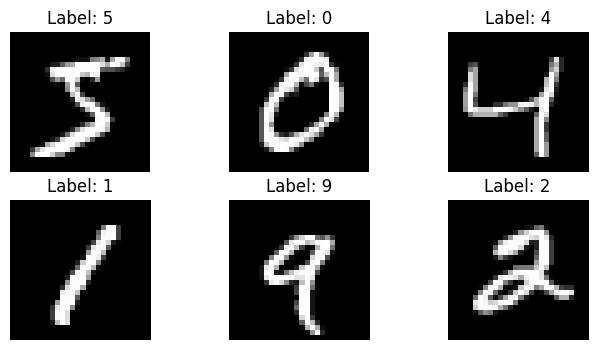

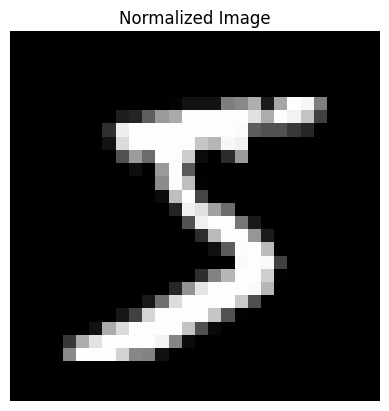

Training data shape: (48000, 28, 28)
Validation data shape: (12000, 28, 28)
Test data shape: (10000, 28, 28)


In [ ]:
# Import required libraries
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# (a) Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Display sample images
plt.figure(figsize=(8,4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

# (b) Normalize the pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Display a normalized image
plt.imshow(X_train[0], cmap='gray')
plt.title("Normalized Image")
plt.axis('off')
plt.show()

# (c) One-hot encode the target labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# (d) Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Print dataset shapes
print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)
print("Test data shape:", X_test.shape)


Accuracy: 0.9219
Precision: 0.9210134567506445
Recall: 0.9208241483711955
F1 Score: 0.9208453359656614
Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best Accuracy: 0.9207000000000001


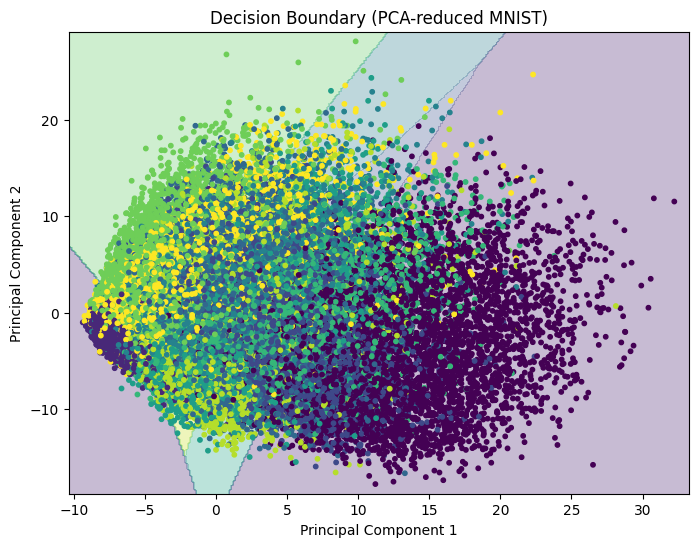

In [ ]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape images (28x28 → 784)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Standardize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# (a) Build Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# (b) Model evaluation
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# (c) Hyperparameter tuning using GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000),
                    param_grid,
                    cv=3,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

# (d) Decision Boundary Visualization using PCA (2D)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train)

# Create meshgrid
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            c=y_train, s=10)
plt.title("Decision Boundary (PCA-reduced MNIST)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


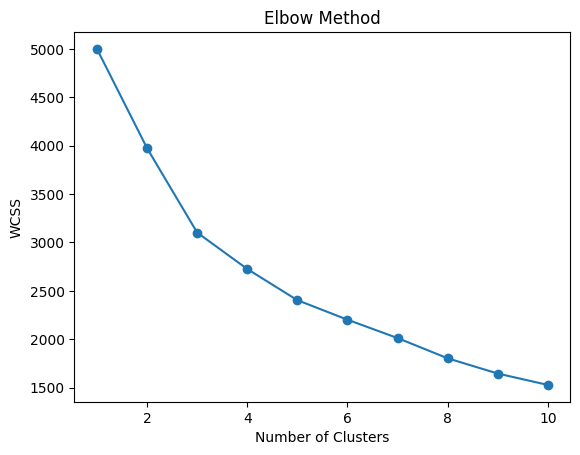


Cluster Characteristics:

              Sales  Quantity    Rating
Cluster                                
0        252.024082  5.027174  7.144022
1        198.160672  4.440678  6.905932
2        662.365038  8.724696  6.808907
3        198.871577  4.150150  7.046847


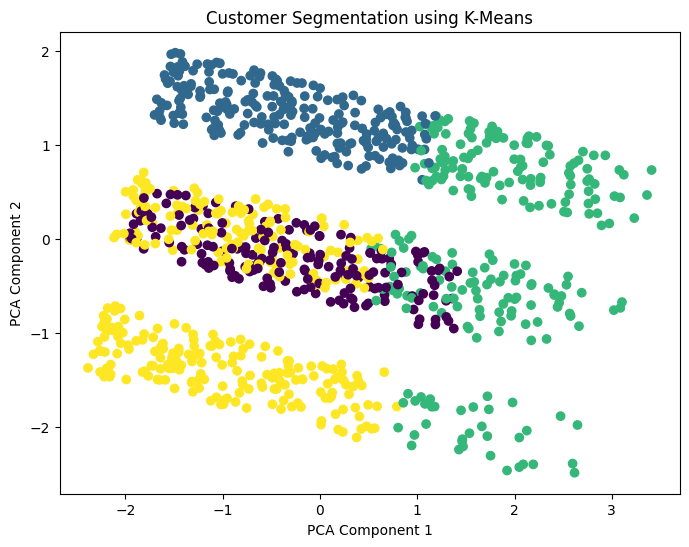

In [ ]:
# ==============================
# K-Means Customer Segmentation
# Supermarket Sales Dataset
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv("supermarket_sales.csv")

# 2. Clean column names
df.columns = df.columns.str.strip()

# 3. Encode demographic features
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Customer type'] = df['Customer type'].map({'Normal': 0, 'Member': 1})

# 4. Select correct features (Sales instead of Total)
X = df[['Sales', 'Quantity', 'Rating', 'Gender', 'Customer type']]

# 5. Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# 7. Apply K-Means (choose K=4 from elbow)
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 8. Cluster analysis
print("\nCluster Characteristics:\n")
print(df.groupby('Cluster')[['Sales', 'Quantity', 'Rating']].mean())

# 9. PCA Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=df['Cluster'])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation using K-Means")
plt.show()
